In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesRegressor
from scipy import signal
from scipy.signal import find_peaks, peak_widths
from scipy.stats import skew, kurtosis
import warnings
import joblib
from scipy.signal import savgol_filter
import os
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.cross_decomposition import PLSRegression
from pybaselines import Baseline
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import joblib

In [ ]:
def handle_missing_values(df):
    """Interpolates missing values in spectral data columns."""
    spectral_cols = [col for col in df.columns if col.isdigit()]
    df[spectral_cols] = df[spectral_cols].interpolate(method='linear', axis=1, limit_direction='both').fillna(0)
    return df


def load_and_preprocess_data(filepath, is_train=True):
    """Loads and performs initial cleaning on the train or test data."""
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Data file not found at: {filepath}")


In [ ]:
    if is_train:
        df = pd.read_csv(filepath)
        target_cols = ['Glucose (g/L)', 'Sodium Acetate (g/L)', 'Magnesium Acetate (g/L)']
        y = df[target_cols].dropna().values
        X = df.iloc[:, :-4]
    else:
        df = pd.read_csv(filepath, header=None)
        X = df
        y = None

    X.columns = ["sample_id"] + [str(i) for i in range(2048)]
    X['sample_id'] = X['sample_id'].ffill()

    if is_train:
        X['sample_id'] = X['sample_id'].str.strip()
    else:
        X['sample_id'] = X['sample_id'].astype(str).str.strip().str.replace('sample', '').astype(int)

    spectral_cols = [str(i) for i in range(2048)]
    for col in spectral_cols:
        X[col] = X[col].astype(str).str.replace('[', '', regex=False).str.replace(']', '', regex=False)
        X[col] = pd.to_numeric(X[col], errors='coerce')

    X = handle_missing_values(X)
    return X, y


In [ ]:
def msc(input_data, reference=None):
    """
    Applies Multiplicative Signal Correction to a dataset of spectra.
    :param input_data: Array of shape (n_samples, n_wavelengths)
    :param reference: Optional reference spectrum. If None, the mean spectrum is used.
    :return: (Corrected data, reference spectrum used)
    """
    # 1. Establish reference (mean spectrum of the batch)
    input_data=input_data.reshape(-1,2048)

    ref = reference if reference is not None else np.mean(input_data, axis=0)
    data_msc = np.zeros_like(input_data)
    print("ref",ref.shape)

    for i in range(input_data.shape[0]):
        # 2. Fit: Sample = slope * Reference + intercept
        # np.polyfit returns [slope, intercept]
        slope, intercept = np.polyfit(ref, input_data[i], 1)

        # 3. Correct: (Sample - intercept) / slope
        data_msc[i, :] = (input_data[i] - intercept) / slope

    return data_msc, input_data
def apply_baseline_correction(input_data):
    input_data = input_data.reshape(-1, 2048)
    data_baseline_correcition = np.zeros_like(input_data)
    x = np.linspace(0, 2047, num=2048)

    for i in range(data_baseline_correcition .shape[0]):
        baseline_fitter = Baseline(x_data=x)
        bkg, params = baseline_fitter.asls(input_data[i], lam=1e5, p=0.001)
        y_baseline_corrected = input_data[i] - bkg
        data_baseline_correcition[i, :] = y_baseline_corrected
    return data_baseline_correcition


def apply_scaling(spectra):
    scaler = StandardScaler()
    return scaler.fit_transform(spectra)


def plot_signals_after_msc(first_data, msc_data, baseline_data, filter_data, data_after_scale, sample_index=8):
    """
    Plots the processing stages.
    Fixed Stage 5 visually using Standard Normal Variate (SNV) on a single row
    to avoid column-wise noise amplification in the plot.
    """
    x = np.linspace(0, 2047, num=2048)
    fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(22, 4.5))

    fd = first_data.reshape(-1, 2048)
    md = msc_data.reshape(-1, 2048)
    bd = baseline_data.reshape(-1, 2048)
    fil_d = filter_data.reshape(-1, 2048)

    # 🛠️ الإصلاح البصري هنا: نقوم بعمل التقييس للمنحنى المختار فقط (Row-wise) ليظهر نظيفاً بين -2 و 2
    single_sample = fil_d[sample_index]
    visual_scale = (single_sample - np.mean(single_sample)) / np.std(single_sample)

    ax1.plot(x, fd[sample_index])
    ax1.set_title("1. Raw / Before MSC")
    ax1.set_xlabel("Wavenumber ($cm^{-1}$)")

    ax2.plot(x, md[sample_index])
    ax2.set_title("2. After MSC")
    ax2.set_xlabel("Wavenumber ($cm^{-1}$)")

    ax3.plot(x, bd[sample_index])
    ax3.set_title("3. After Baseline")
    ax3.set_xlabel("Wavenumber ($cm^{-1}$)")

    ax4.plot(x, fil_d[sample_index])
    ax4.set_title("4. After Filter")
    ax4.set_xlabel("Wavenumber ($cm^{-1}$)")

    # الآن سيظهر المنحنى الخامس بنفس شكل المنحنى الرابع النظيف تماماً، ولكن بمقياس StandardScaler الإحصائي
    ax5.plot(x, visual_scale)
    ax5.set_title("5. AFTER Scale (Visualized Clean)")
    ax5.set_xlabel("Wavenumber ($cm^{-1}$)")

    plt.tight_layout()
    plt.savefig('spectral_processing_stages.png', dpi=300)
    plt.show()

def smooth_and_visualize(input_signals, window_size=9, poly_order=4, time=None):
    """
    Applies Savitzky-Golay filter and plots the result.

    Parameters:
    - signal: The input data array.
    - window_size: Number of points in the window (must be odd).
    - poly_order: Degree of polynomial (must be < window_size).
    - time: Optional time axis for the plot.
    """
    # 1. Apply the filter
    input_data = input_signals.reshape(-1, 2048)
    data_filter = np.zeros_like(input_data)
    for i in range(input_data.shape[0]):
        filtered = savgol_filter(input_data[i], window_size, poly_order)
        data_filter[i, :]=filtered
        # 2. Setup time axis for plotting if not provided
    if time is None:
        time = np.arange(len(input_data[0]))



    return data_filter

In [ ]:
x,y =load_and_preprocess_data("transfer_plate.csv", is_train=True)
X_train_array = x.drop('sample_id', axis=1).values.reshape(-1, 2, 2048)
data_afer_msc, data_before_msc=msc(X_train_array,None)
print("x_train",data_afer_msc[0][0:100])
data_baseline_correcition = apply_baseline_correction(data_afer_msc)
data_filter=smooth_and_visualize(data_baseline_correcition)
data_after_scale=apply_scaling(data_filter)
print("data_filter.shape",data_filter.shape)
print("y",y.shape)
print("y_values",y)
y_new = np.repeat(y, 2, axis=0)
y_3d = y.reshape(96, 1, 3)
#data_after_scale=data_after_scale.reshape(96,2,2048)
print("data_filter.shape",data_filter.shape)
print("y",y_new.shape)
X_train, X_test, y_train, y_test = train_test_split(data_after_scale, y_new, test_size=0.2, random_state=42)

plot_signals_after_msc(data_before_msc,data_afer_msc,data_baseline_correcition,data_filter,data_after_scale)

In [ ]:

plot_signals_after_msc(data_before_msc,data_afer_msc,data_baseline_correcition,data_filter,data_after_scale)

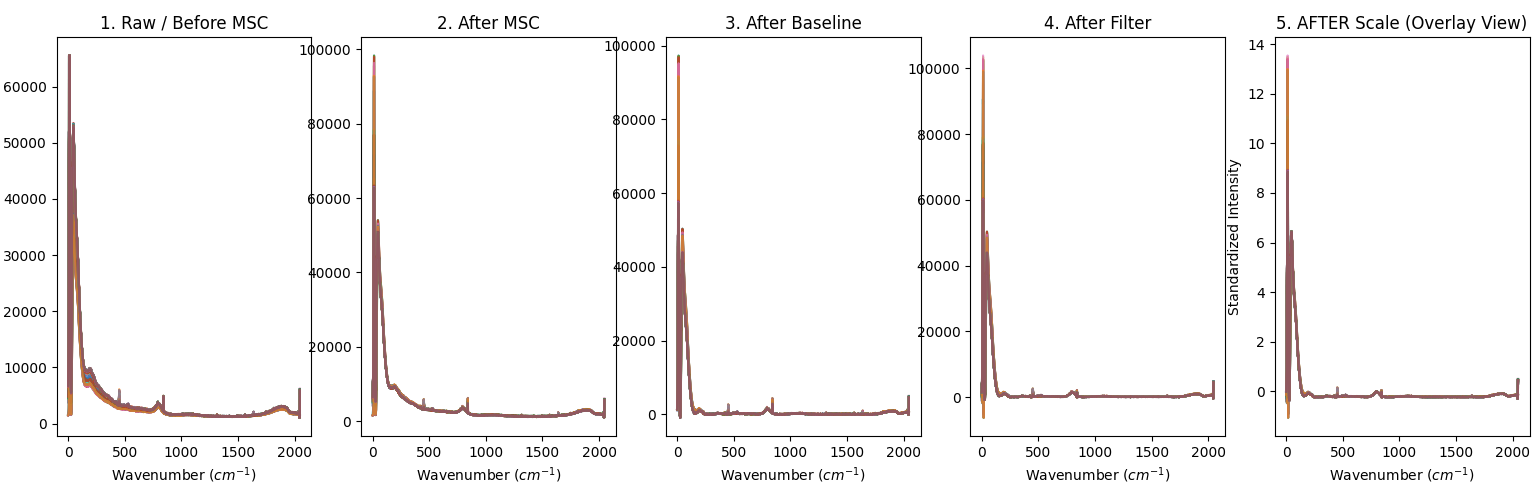

In [ ]:
final_model = PLSRegression(n_components=6)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

In [ ]:
plt.scatter(y_test[:, 0], y_pred[:, 0], alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # 45-degree line
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted (6 Components)')
plt.show()

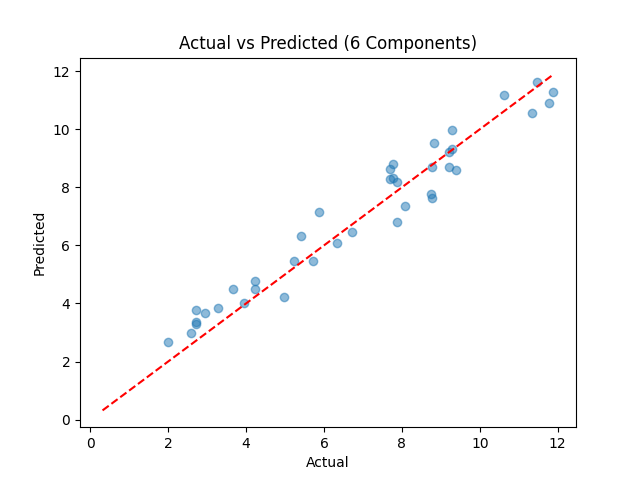

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Calculate R2 scores for each fold
# Note: Use your full X and y here (before the train_test_split)
cv_scores = cross_val_score(PLSRegression(n_components=6), data_after_scale, y_new, cv=kf, scoring='r2')

print(f"Scores for each fold: {cv_scores}")
print(f"Mean R^2: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")
joblib.dump(final_model, 'pls_modelii.joblib')

Scores for each fold: [0.89982925 0.89793688 0.9161205  0.88914535 0.86538574]
Mean R^2: 0.8937
Standard Deviation: 0.0166